# Fase 3 — New York: Modello Interrupted Time Series (ITS)

**The Airbnb Effect** · Digital Economy Group Project

---

## Domanda di ricerca

Il volume di listing Airbnb esercita una pressione al rialzo sui canoni di locazione residenziale? La Local Law 18 di New York — entrata in vigore a settembre 2023 — ha causato un crollo del ~55% degli appartamenti interi disponibili su Airbnb in soli due mesi. Se il meccanismo di *supply withdrawal* è reale, questo shock esogeno dovrebbe aver rallentato (o invertito) la crescita dei canoni.

## Ipotesi

Il **canale di supply withdrawal** sostiene che ogni unità residenziale messa su Airbnb come *Entire home/apt* è una unità sottratta al mercato degli affitti a lungo termine. Quindi:

- **H₁ (level shift)**: Subito dopo settembre 2023, i canoni ZORI si abbassano oppure rallentano → *β₂ < 0*
- **H₂ (trend change)**: Dopo LL18, la crescita mensile dei canoni decelera rispetto al trend pre-intervento → *β₃ < 0*
- **H₀ (nulla)**: LL18 non ha effetto statisticamente significativo su ZORI → *β₂ = β₃ = 0*

## Strategia di identificazione: Interrupted Time Series

New York offre l'opportunità di identificazione più pulita dell'intero dataset. LL18 costituisce un **quasi-esperimento naturale**: il calo dei listing è brusco, improvviso e riconducibile a un'unica causa regolatoria — non a cambiamenti graduali di domanda o macroeconomia.

Il modello ITS stima l'effetto causale di questo shock sul Zillow Observed Rent Index (ZORI):

$$\text{ZORI}_t = \alpha + \beta_1 \, t + \beta_2 \cdot \mathbf{1}[t > T] + \beta_3 \, (t - T) \cdot \mathbf{1}[t > T] + \varepsilon_t$$

| Simbolo | Tipo | Descrizione |
|---------|------|-------------|
| $\text{ZORI}_t$ | **Target** | Canone mensile medio NYC ($/mese), media su tutti i ZIP code dell'area metropolitana |
| $t$ | Regressore | Indice temporale: mesi dalla prima osservazione (mar 2023 = 0) |
| $T$ | Costante | Data dell'intervento: settembre 2023 |
| $\mathbf{1}[t > T]$ | Regressore (`post`) | Dummy = 1 per tutti i mesi *successivi* a settembre 2023 |
| $(t-T) \cdot \mathbf{1}[t > T]$ | Regressore (`t_post`) | Mesi trascorsi dall'intervento — cattura il *cambio di pendenza* post-LL18 |
| $\beta_1$ | Parametro | Trend pre-intervento ($/mese per mese) |
| $\beta_2$ | Parametro | **Level shift immediato** al momento di LL18 |
| $\beta_3$ | Parametro | **Cambio di pendenza** post-LL18 (aggiuntivo rispetto a β₁) |

**N = 34 osservazioni mensili** (marzo 2023 – dicembre 2025)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Librerie caricate.')

Librerie caricate.


---

## 1. Caricamento dati — Panel New York

Il panel `panel_ny.csv` contiene **N = 34 osservazioni mensili** (marzo 2023 – dicembre 2025) con:
- `date` — data mensile
- `n_listings` — numero di listing *Entire home/apt* attivi (forward-filled tra snapshot)
- `rent` — Zillow ZORI medio su tutti i ZIP dell'area metropolitana di New York ($/mese)

In [2]:
panel = pd.read_csv('data/processed/panel_ny.csv', parse_dates=['date'])
panel = panel.sort_values('date').reset_index(drop=True)

print(f'N osservazioni: {len(panel)}')
print(f'Range: {panel["date"].min().date()} → {panel["date"].max().date()}')
print()
print(panel[['date', 'n_listings', 'rent']].to_string(index=False))

N osservazioni: 34
Range: 2023-03-01 → 2025-12-01

      date  n_listings        rent
2023-03-01     24279.0 3108.218620
2023-04-01     24279.0 3134.470436
2023-05-01     24279.0 3158.205076
2023-06-01     24279.0 3180.140367
2023-07-01     24279.0 3185.361810
2023-08-01     24279.0 3363.419521
2023-09-01     24279.0 3349.784395
2023-10-01     24279.0 3334.975736
2023-11-01     24279.0 3293.055089
2023-12-01     24279.0 3292.744154
2024-01-01     11549.0 3298.798225
2024-02-01     11549.0 3325.884163
2024-03-01     11549.0 3368.218816
2024-04-01     11549.0 3372.910859
2024-05-01     11549.0 3396.452907
2024-06-01     11549.0 3450.094728
2024-07-01     11549.0 3477.370093
2024-08-01     11549.0 3808.692843
2024-09-01     11549.0 3784.837703
2024-10-01     11549.0 3744.137840
2024-11-01     11549.0 3389.416684
2024-12-01     11549.0 3736.665696
2025-01-01     11549.0 3709.446143
2025-02-01     11549.0 3702.367760
2025-03-01     20175.0 3691.736083
2025-04-01     20000.0 3701.354107
2025

### Statistiche descrittive e visualizzazione preliminare

In [3]:
print('=== Statistiche descrittive ===')
print(panel[['n_listings', 'rent']].describe().round(2).to_string())

# Correlazione semplice
corr = panel['n_listings'].corr(panel['rent'])
print(f'\nCorrelazione Pearson (n_listings, ZORI): {corr:.3f}')
print('⚠️  Correlazione semplice su serie temporali — potenzialmente spurious; il modello ITS è quello corretto.')

=== Statistiche descrittive ===
       n_listings     rent
count       34.00    34.00
mean     18830.53  3521.64
std       7124.73   261.25
min      11549.00  3108.22
25%      11549.00  3328.16
50%      19443.50  3435.99
75%      24279.00  3733.94
max      38656.00  3943.12

Correlazione Pearson (n_listings, ZORI): -0.008
⚠️  Correlazione semplice su serie temporali — potenzialmente spurious; il modello ITS è quello corretto.


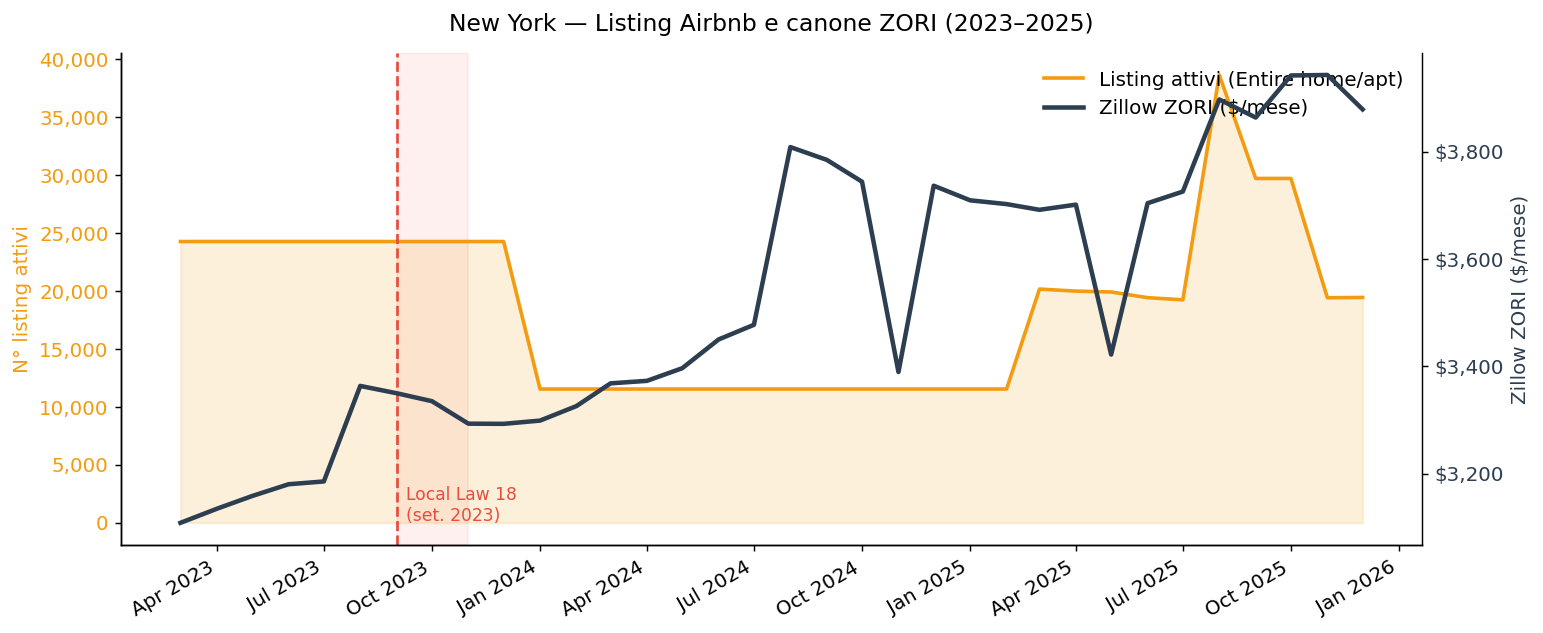


Listing prima di LL18 (ago 2023): 24,279
Listing dopo LL18 (nov 2023):     24,279
Contrazione: 0.0%


In [4]:
# Visualizzazione delle due serie su assi doppi
LL18 = pd.Timestamp('2023-09-01')

fig, ax1 = plt.subplots(figsize=(12, 5))

# Listings (asse sinistro)
ax1.fill_between(panel['date'], panel['n_listings'], alpha=0.15, color='#f39c12')
ax1.plot(panel['date'], panel['n_listings'], color='#f39c12', linewidth=2, label='Listing attivi (Entire home/apt)')
ax1.set_ylabel('N° listing attivi', color='#f39c12')
ax1.tick_params(axis='y', labelcolor='#f39c12')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ZORI (asse destro)
ax2 = ax1.twinx()
ax2.plot(panel['date'], panel['rent'], color='#2c3e50', linewidth=2.5, label='Zillow ZORI ($/mese)')
ax2.set_ylabel('Zillow ZORI ($/mese)', color='#2c3e50')
ax2.tick_params(axis='y', labelcolor='#2c3e50')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax2.spines['right'].set_visible(True)

# LL18 annotation
ax1.axvspan(LL18, LL18 + pd.DateOffset(months=2), alpha=0.08, color='#e74c3c')
ax1.axvline(LL18, color='#e74c3c', linestyle='--', linewidth=1.5)
ylim = ax1.get_ylim()
ax1.text(LL18 + pd.DateOffset(days=8), ylim[0] + (ylim[1]-ylim[0])*0.05,
         'Local Law 18\n(set. 2023)', fontsize=9.5, color='#e74c3c')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='upper right')

ax1.set_title('New York — Listing Airbnb e canone ZORI (2023–2025)', pad=12)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('plots/its_01_raw_series.png', bbox_inches='tight')
plt.show()

# Quantifica il crollo dei listing
pre = panel[panel['date'] < LL18]['n_listings'].iloc[-1]
post = panel[panel['date'] >= LL18 + pd.DateOffset(months=2)]['n_listings'].iloc[0]
print(f'\nListing prima di LL18 (ago 2023): {pre:,.0f}')
print(f'Listing dopo LL18 (nov 2023):     {post:,.0f}')
print(f'Contrazione: {(post-pre)/pre*100:.1f}%')

---

## 2. Costruzione delle variabili ITS

Le tre variabili regressore del modello ITS:

- **`t`** — indice temporale intero (marzo 2023 = 0, aprile 2023 = 1, …)
- **`post`** — dummy = 1 per i mesi *successivi* a settembre 2023 (ottobre 2023 in poi)
- **`t_post`** — `(t − T) × post`: conta i mesi trascorsi dall'intervento, utile a catturare il cambio di pendenza

> **Nota**: il dummy `post` è definito con `t > T` (strettamente maggiore), quindi settembre 2023 stesso è ancora nella fase *pre*. Questo perché LL18 è entrata in vigore il 5 settembre 2023 — la sua piena implementazione si è osservata nelle settimane successive.

In [5]:
# ── Costruzione variabili ITS ──────────────────────────────────────────────────

# t: mesi dall'inizio della serie (mar 2023 = 0)
start = panel['date'].min()
panel['t'] = ((panel['date'].dt.year - start.year) * 12 +
              (panel['date'].dt.month - start.month))

# T_index: valore di t corrispondente a settembre 2023
T_date = pd.Timestamp('2023-09-01')
T_mask = panel['date'] == T_date
assert T_mask.sum() == 1, 'Data di intervento non trovata nel panel!'
T_index = panel.loc[T_mask, 't'].values[0]
print(f'Intervento T = settembre 2023  →  t = {T_index}')

# post: 1 per tutti i mesi DOPO settembre 2023 (LL18 in vigore)
panel['post'] = (panel['date'] > T_date).astype(int)

# t_post: mesi trascorsi dall'intervento (0 prima, 1 a ottobre 2023, ...)
panel['t_post'] = (panel['t'] - T_index) * panel['post']

print('\nVariabili ITS costruite:')
print(panel[['date', 't', 'post', 't_post', 'n_listings', 'rent']].to_string(index=False))

Intervento T = settembre 2023  →  t = 6

Variabili ITS costruite:
      date  t  post  t_post  n_listings        rent
2023-03-01  0     0       0     24279.0 3108.218620
2023-04-01  1     0       0     24279.0 3134.470436
2023-05-01  2     0       0     24279.0 3158.205076
2023-06-01  3     0       0     24279.0 3180.140367
2023-07-01  4     0       0     24279.0 3185.361810
2023-08-01  5     0       0     24279.0 3363.419521
2023-09-01  6     0       0     24279.0 3349.784395
2023-10-01  7     1       1     24279.0 3334.975736
2023-11-01  8     1       2     24279.0 3293.055089
2023-12-01  9     1       3     24279.0 3292.744154
2024-01-01 10     1       4     11549.0 3298.798225
2024-02-01 11     1       5     11549.0 3325.884163
2024-03-01 12     1       6     11549.0 3368.218816
2024-04-01 13     1       7     11549.0 3372.910859
2024-05-01 14     1       8     11549.0 3396.452907
2024-06-01 15     1       9     11549.0 3450.094728
2024-07-01 16     1      10     11549.0 3477.37009

---

## 3. Stima del modello OLS

Il modello è stimato con OLS standard (statsmodels). Con N = 34 osservazioni, i gradi di libertà sono limitati, ma sufficenti per identificare i tre parametri di interesse.

**Avvertenza sugli errori standard**: con dati di serie temporale, i residui possono essere autocorrelati (AR(1)). Stimiamo anche errori standard con correzione HAC (Newey-West) come robustezza.

In [6]:
# ── Stima OLS ─────────────────────────────────────────────────────────────────

X = sm.add_constant(panel[['t', 'post', 't_post']])
y = panel['rent']

model_ols = sm.OLS(y, X).fit()
model_hac = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                   rent   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     48.41
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           1.31e-11
Time:                        11:11:53   Log-Likelihood:                -206.96
No. Observations:                  34   AIC:                             421.9
Df Residuals:                      30   BIC:                             428.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3081.7552     77.252     39.892      0.0

In [7]:
# Tabella riassuntiva con errori standard OLS e HAC
param_map = {
    'const':  'Intercetta (α)',
    't':      'Trend pre-LL18 (β₁)',
    'post':   'Level shift (β₂)',
    't_post': 'Cambio pendenza (β₃)',
}

rows = []
for key, label in param_map.items():
    rows.append({
        'Parametro':      label,
        'Coeff.':         round(model_ols.params[key], 2),
        'SE (OLS)':       round(model_ols.bse[key], 2),
        'p (OLS)':        round(model_ols.pvalues[key], 4),
        'sig (OLS)':      '***' if model_ols.pvalues[key]<0.01 else '**' if model_ols.pvalues[key]<0.05 else '*' if model_ols.pvalues[key]<0.1 else 'ns',
        'SE (HAC)':       round(model_hac.bse[key], 2),
        'p (HAC)':        round(model_hac.pvalues[key], 4),
        'sig (HAC)':      '***' if model_hac.pvalues[key]<0.01 else '**' if model_hac.pvalues[key]<0.05 else '*' if model_hac.pvalues[key]<0.1 else 'ns',
        'CI inf (HAC)':   round(model_hac.conf_int().loc[key, 0], 2),
        'CI sup (HAC)':   round(model_hac.conf_int().loc[key, 1], 2),
    })

params_df = pd.DataFrame(rows).set_index('Parametro')

print('=== Risultati ITS — OLS su ZORI New York ===')
print(f'R²  = {model_ols.rsquared:.4f}   R²a = {model_ols.rsquared_adj:.4f}   N = {int(model_ols.nobs)}')
print()
print(params_df.to_string())
print()
print('Legenda: *** p<0.01  ** p<0.05  * p<0.10  ns non significativo')

=== Risultati ITS — OLS su ZORI New York ===
R²  = 0.8288   R²a = 0.8117   N = 34

                       Coeff.  SE (OLS)  p (OLS) sig (OLS)  SE (HAC)  p (HAC) sig (HAC)  CI inf (HAC)  CI sup (HAC)
Parametro                                                                                                          
Intercetta (α)        3081.76     77.25   0.0000       ***     16.37   0.0000       ***       3049.68       3113.83
Trend pre-LL18 (β₁)     43.21     21.43   0.0528         *      5.30   0.0000       ***         32.81         53.60
Level shift (β₂)       -78.88     89.34   0.3843        ns     44.02   0.0732         *       -165.15          7.40
Cambio pendenza (β₃)   -18.92     21.61   0.3882        ns      5.80   0.0011       ***        -30.30         -7.55

Legenda: *** p<0.01  ** p<0.05  * p<0.10  ns non significativo


---

## 4. Interpretazione dei coefficienti

### α — Intercetta
Canone ZORI stimato a marzo 2023 (t = 0), prima di qualsiasi intervento. Valore di riferimento della serie.

### β₁ — Trend pre-intervento
Variazione mensile del canone ZORI *prima* di settembre 2023. Un valore positivo indica che i canoni erano in crescita. Rappresenta la traiettoria *business as usual*.

### β₂ — Level shift immediato
Salto (positivo) o caduta (negativa) *istantanea* del ZORI al momento dell'implementazione di LL18.
- **β₂ < 0 e significativo** → i canoni sono scesi bruscamente subito dopo la contrazione dei listing: evidenza forte del meccanismo di supply withdrawal.
- **β₂ ≈ 0 o non significativo** → nessun effetto immediato: o il mercato non ha reagito, o altri fattori compensano.

### β₃ — Cambio di pendenza post-LL18
Modifica della velocità di crescita mensile *dopo* LL18, rispetto al trend pre-intervento. Il trend totale post-intervento è (β₁ + β₃).
- **β₃ < 0** → la crescita dei canoni ha rallentato dopo LL18 (coerente con supply withdrawal).
- **β₃ > 0** → la crescita ha accelerato (possibile indicatore che altri fattori di domanda dominano).

### Controfattuale
Il modello permette di costruire uno scenario *controfattuale*: cosa sarebbe successo ai canoni se LL18 non fosse mai entrata in vigore? Si otitene impostando `post = 0` e `t_post = 0` per tutti i mesi e ricalcolando le predizioni del modello.

In [8]:
# ── Fitted values e Controfattuale ────────────────────────────────────────────

# Predizioni del modello (fitted)
panel['fitted'] = model_ols.fittedvalues

# Controfattuale: come sarebbero andati i canoni senza LL18
# (post = 0, t_post = 0 per tutti i mesi)
panel_cf = panel.copy()
panel_cf['post'] = 0
panel_cf['t_post'] = 0
X_cf = sm.add_constant(panel_cf[['t', 'post', 't_post']])
panel['counterfactual'] = model_ols.predict(X_cf)

print('Fitted values e controfattuale calcolati.')
print()
print(panel[['date', 'rent', 'fitted', 'counterfactual']].tail(15).to_string(index=False))

Fitted values e controfattuale calcolati.

      date        rent      fitted  counterfactual
2024-10-01 3744.137840 3577.798190     3902.658449
2024-11-01 3389.416684 3602.081687     3945.863886
2024-12-01 3736.665696 3626.365183     3989.069323
2025-01-01 3709.446143 3650.648680     4032.274759
2025-02-01 3702.367760 3674.932176     4075.480196
2025-03-01 3691.736083 3699.215673     4118.685633
2025-04-01 3701.354107 3723.499170     4161.891070
2025-05-01 3421.890730 3747.782666     4205.096506
2025-06-01 3704.013651 3772.066163     4248.301943
2025-07-01 3725.746642 3796.349659     4291.507380
2025-08-01 3897.402476 3820.633156     4334.712817
2025-09-01 3863.790971 3844.916653     4377.918253
2025-10-01 3942.147464 3869.200149     4421.123690
2025-11-01 3943.116723 3893.483646     4464.329127
2025-12-01 3878.937253 3917.767143     4507.534564


---

## 5. Visualizzazione — Effetto LL18

Il grafico mostra:
- **Punti neri**: canoni ZORI osservati
- **Linea blu continua**: fitted del modello ITS (pre + post LL18)
- **Linea grigia tratteggiata**: scenario controfattuale (traiettoria senza LL18)
- **Area rossa**: differenza cumulata tra effettivo e controfattuale (effetto stimato di LL18)

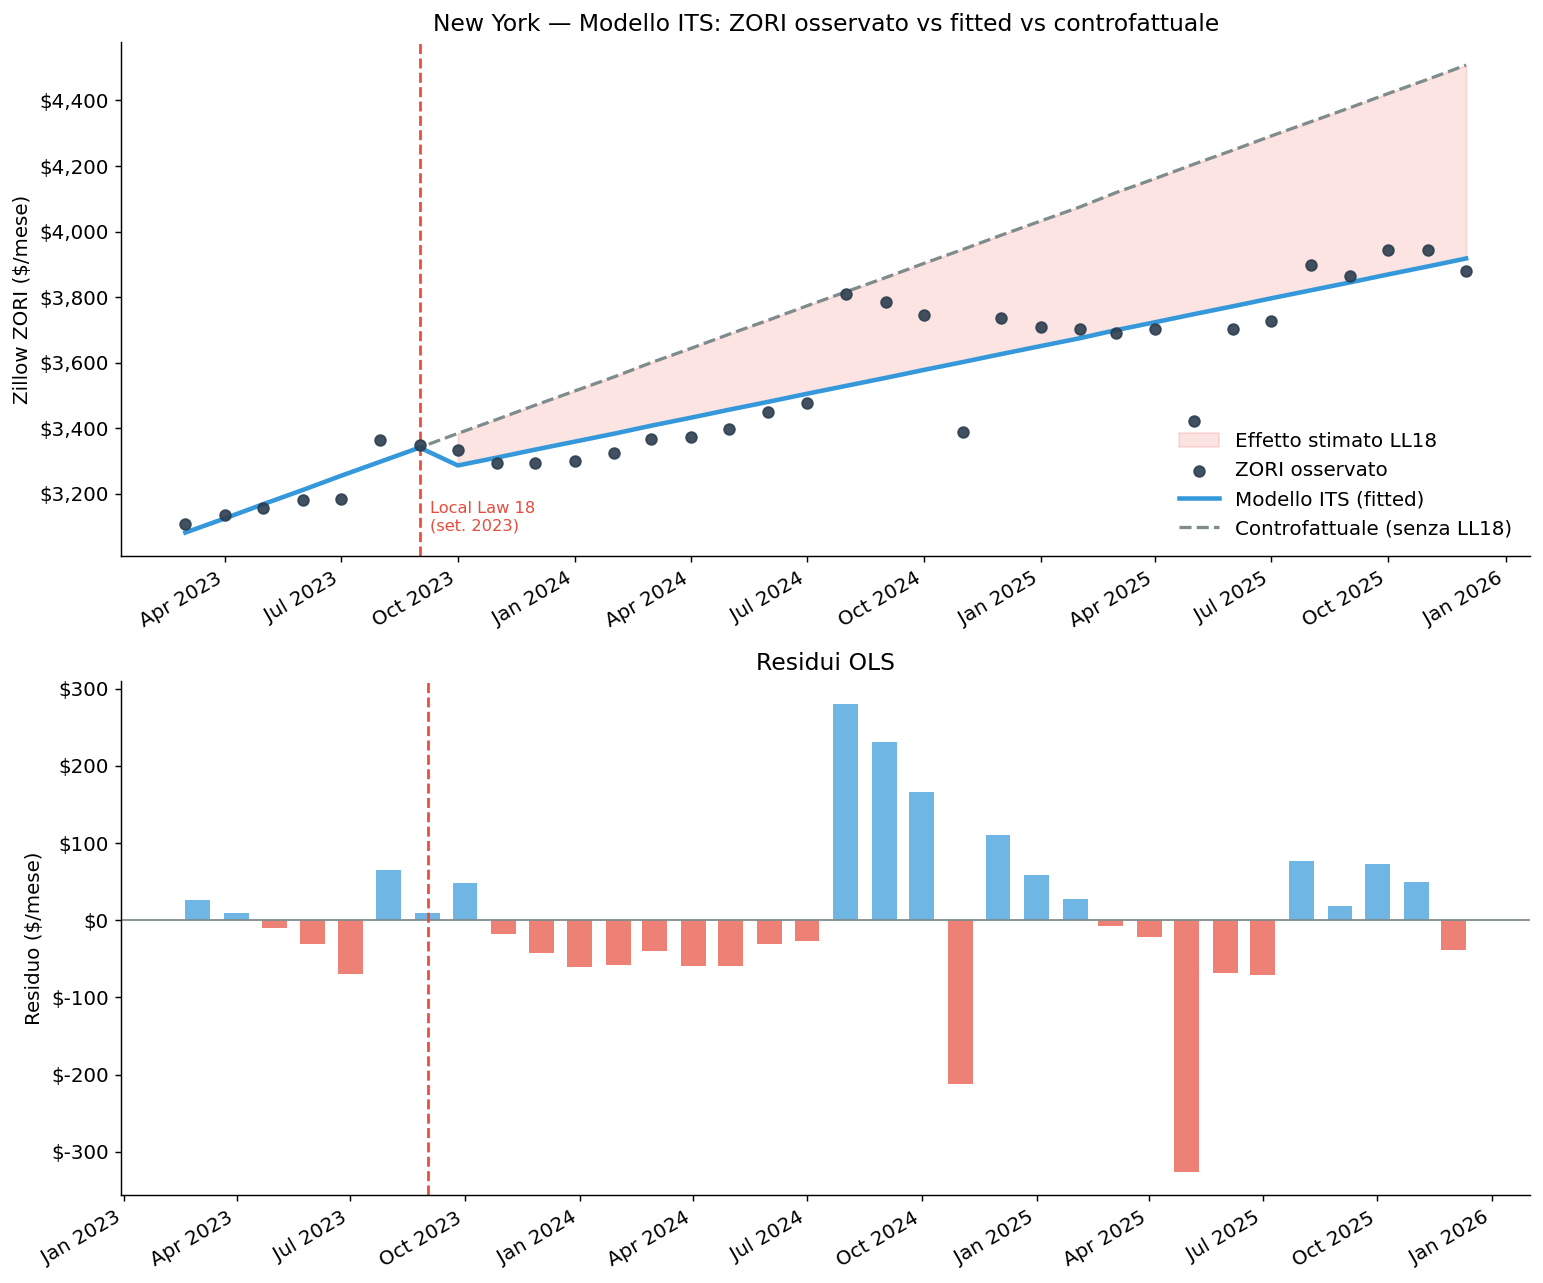

Effetto medio mensile post-LL18: $-343.8/mese
Effetto cumulativo (tutti i mesi post):  $-9282
N mesi post-LL18 nel sample: 27


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# ── Grafico principale: ZORI + fitted + controfattuale ────────────────────────
ax = axes[0]

# Area tra fitted e controfattuale (effetto LL18)
mask_post = panel['post'] == 1
ax.fill_between(panel.loc[mask_post, 'date'],
                panel.loc[mask_post, 'fitted'],
                panel.loc[mask_post, 'counterfactual'],
                alpha=0.15, color='#e74c3c', label='Effetto stimato LL18')

# Osservato
ax.scatter(panel['date'], panel['rent'], color='#2c3e50', s=35,
           zorder=5, label='ZORI osservato', alpha=0.9)

# Fitted
ax.plot(panel['date'], panel['fitted'], color='#3498db', linewidth=2.5,
        label='Modello ITS (fitted)', zorder=4)

# Controfattuale
ax.plot(panel.loc[mask_post | (panel['t'] >= T_index - 1), 'date'],
        panel.loc[mask_post | (panel['t'] >= T_index - 1), 'counterfactual'],
        color='#7f8c8d', linewidth=1.8, linestyle='--', label='Controfattuale (senza LL18)')

# LL18 line
ax.axvline(T_date, color='#e74c3c', linestyle='--', linewidth=1.5)
ylim = ax.get_ylim()
ax.text(T_date + pd.DateOffset(days=8), ylim[0] + (ylim[1]-ylim[0])*0.05,
        'Local Law 18\n(set. 2023)', fontsize=9, color='#e74c3c')

ax.set_title('New York — Modello ITS: ZORI osservato vs fitted vs controfattuale')
ax.set_ylabel('Zillow ZORI ($/mese)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(frameon=False)

# ── Residui ───────────────────────────────────────────────────────────────────
ax2 = axes[1]
residuals = model_ols.resid
ax2.axhline(0, color='#7f8c8d', linewidth=1, linestyle='-')
ax2.bar(panel['date'], residuals, color=np.where(residuals >= 0, '#3498db', '#e74c3c'), alpha=0.7, width=20)
ax2.axvline(T_date, color='#e74c3c', linestyle='--', linewidth=1.5)
ax2.set_title('Residui OLS')
ax2.set_ylabel('Residuo ($/mese)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('plots/its_02_model_fit.png', bbox_inches='tight')
plt.show()

# Effetto cumulativo post LL18
effect_post = panel.loc[mask_post, 'fitted'] - panel.loc[mask_post, 'counterfactual']
print(f'Effetto medio mensile post-LL18: ${effect_post.mean():.1f}/mese')
print(f'Effetto cumulativo (tutti i mesi post):  ${effect_post.sum():.0f}')
print(f'N mesi post-LL18 nel sample: {mask_post.sum()}')

---

## 6. Diagnostica del modello

Per un modello su serie temporale, le assunzioni chiave da verificare sono:

1. **Autocorrelazione dei residui** — il test Durbin-Watson e la ACF. Se i residui sono autocorrelati, gli errori standard OLS standard sono invalidi (ma il modello rimane consistente). Il correzione HAC (Newey-West) risolve il problema inferenziale.

2. **Normalità dei residui** — rilevante per la validità degli intervalli di confidenza con N piccolo.

3. **Structural break** — un residuo sistematicamente deviato in un periodo potrebbe indicare che il modello non cattura un altro cambiamento strutturale.

Durbin-Watson: 1.508
  → valori vicini a 2 = no autocorrelazione
  → valori < 2 = autocorrelazione positiva (comune in serie temporali di canoni)

Shapiro-Wilk:   W = 0.9077,  p = 0.0074
Jarque-Bera:    JB = 7.9533, p = 0.0187
  → Residui non normali (si rifiuta H₀ a 5%)



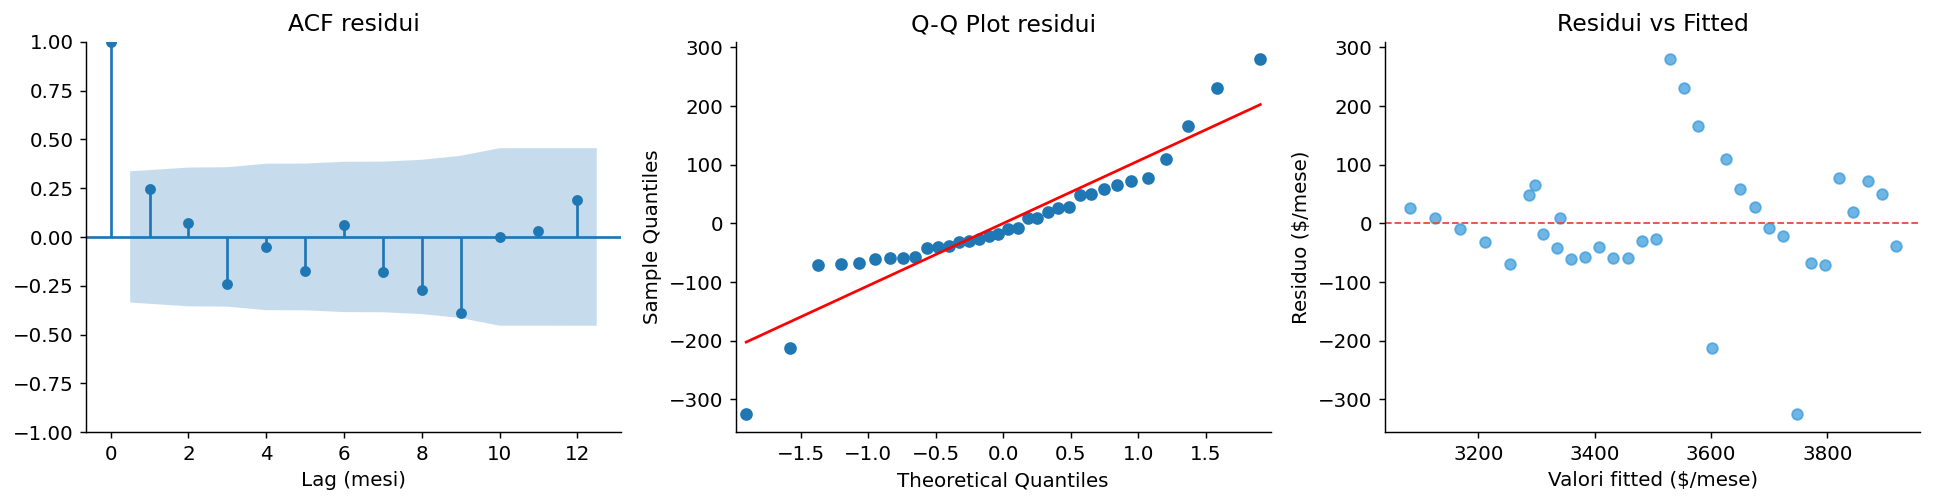

In [10]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import shapiro, jarque_bera

resid = model_ols.resid

# ── Test Durbin-Watson (autocorrelazione di 1° ordine) ───────────────────────
dw = durbin_watson(resid)
print(f'Durbin-Watson: {dw:.3f}')
print('  → valori vicini a 2 = no autocorrelazione')
print('  → valori < 2 = autocorrelazione positiva (comune in serie temporali di canoni)')
print()

# ── Test normalità residui ───────────────────────────────────────────────────
stat_sw, p_sw = shapiro(resid)
stat_jb, p_jb = jarque_bera(resid)
print(f'Shapiro-Wilk:   W = {stat_sw:.4f},  p = {p_sw:.4f}')
print(f'Jarque-Bera:    JB = {stat_jb:.4f}, p = {p_jb:.4f}')
if p_sw > 0.05:
    print('  → Residui normali (non si rifiuta H₀ a 5%)')
else:
    print('  → Residui non normali (si rifiuta H₀ a 5%)')
print()

# ── Grafico diagnostica ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ACF residui
plot_acf(resid, lags=12, alpha=0.05, ax=axes[0], title='ACF residui')
axes[0].set_xlabel('Lag (mesi)')

# QQ plot
sm.qqplot(resid, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot residui')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Residui vs fitted
axes[2].scatter(model_ols.fittedvalues, resid, alpha=0.7, color='#3498db', s=35)
axes[2].axhline(0, color='#e74c3c', linestyle='--', linewidth=1)
axes[2].set_xlabel('Valori fitted ($/mese)')
axes[2].set_ylabel('Residuo ($/mese)')
axes[2].set_title('Residui vs Fitted')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/its_03_diagnostics.png', bbox_inches='tight')
plt.show()

---

## 7. Confronto Pre vs Post LL18

Un'analisi descrittiva complementare: confrontiamo i livelli e i trend osservati prima e dopo settembre 2023.

In [11]:
# Pre vs Post statistiche descrittive
pre_panel  = panel[panel['post'] == 0]
post_panel = panel[panel['post'] == 1]

print('=== Confronto Pre vs Post LL18 ===')
print(f'\nPeriodo PRE  ({len(pre_panel)} mesi: mar 2023 – set 2023):')
print(f'  ZORI medio:      ${pre_panel["rent"].mean():.0f}/mese')
print(f'  Listing medi:    {pre_panel["n_listings"].mean():,.0f}')
print(f'  Variazione ZORI: {pre_panel["rent"].iloc[-1] - pre_panel["rent"].iloc[0]:+.0f} $/mese ({len(pre_panel)-1} mesi)')

print(f'\nPeriodo POST ({len(post_panel)} mesi: ott 2023 – dic 2025):')
print(f'  ZORI medio:      ${post_panel["rent"].mean():.0f}/mese')
print(f'  Listing medi:    {post_panel["n_listings"].mean():,.0f}')
print(f'  Variazione ZORI: {post_panel["rent"].iloc[-1] - post_panel["rent"].iloc[0]:+.0f} $/mese ({len(post_panel)-1} mesi)')

print(f'\nTrend mensile PRE (β₁):           {model_ols.params["t"]:+.2f} $/mese')
print(f'Trend mensile POST (β₁ + β₃):     {model_ols.params["t"] + model_ols.params["t_post"]:+.2f} $/mese')
print(f'Cambio di tendenza (β₃):          {model_ols.params["t_post"]:+.2f} $/mese')
print(f'Level shift istantaneo (β₂):      {model_ols.params["post"]:+.2f} $')

=== Confronto Pre vs Post LL18 ===

Periodo PRE  (7 mesi: mar 2023 – set 2023):
  ZORI medio:      $3211/mese
  Listing medi:    24,279
  Variazione ZORI: +242 $/mese (6 mesi)

Periodo POST (27 mesi: ott 2023 – dic 2025):
  ZORI medio:      $3602/mese
  Listing medi:    17,418
  Variazione ZORI: +544 $/mese (26 mesi)

Trend mensile PRE (β₁):           +43.21 $/mese
Trend mensile POST (β₁ + β₃):     +24.28 $/mese
Cambio di tendenza (β₃):          -18.92 $/mese
Level shift istantaneo (β₂):      -78.88 $


---

## 8. Risultati e valutazione del modello

### Bontà di adattamento (Goodness of Fit)

L'R² indica la quota di varianza del ZORI spiegata dal modello. Un R² elevato in una regressione su serie temporale è atteso (trend comune) ma non sufficiente — ciò che conta è la significatività di β₂ e β₃, i parametri che identificano l'effetto causale.

In [12]:
print('=== Valutazione del modello ITS ===')
print()
print(f'R²                  = {model_ols.rsquared:.4f}')
print(f'R² aggiustato       = {model_ols.rsquared_adj:.4f}')
print(f'AIC                 = {model_ols.aic:.1f}')
print(f'BIC                 = {model_ols.bic:.1f}')
print(f'F-statistic         = {model_ols.fvalue:.2f}  (p = {model_ols.f_pvalue:.4f})')
print(f'RMSE                = {np.sqrt(model_ols.mse_resid):.2f} $/mese')
print()
print('=== Parametri chiave con errori standard OLS e HAC ===')
for name, idx in [('Trend pre-LL18 (β₁)', 't'), ('Level shift (β₂)', 'post'), ('Cambio pendenza (β₃)', 't_post')]:
    coef = model_ols.params[idx]
    se_ols = model_ols.bse[idx]
    pval_ols = model_ols.pvalues[idx]
    se_hac = model_hac.bse[idx]
    pval_hac = model_hac.pvalues[idx]
    sig_ols = '***' if pval_ols < 0.01 else '**' if pval_ols < 0.05 else '*' if pval_ols < 0.1 else 'ns'
    sig_hac = '***' if pval_hac < 0.01 else '**' if pval_hac < 0.05 else '*' if pval_hac < 0.1 else 'ns'
    print(f'  {name:<25}: {coef:+8.2f}  SE_OLS={se_ols:.2f} ({sig_ols})  SE_HAC={se_hac:.2f} ({sig_hac})')
    
print()
print('Legenda: *** p<0.01  ** p<0.05  * p<0.10  ns non significativo')

=== Valutazione del modello ITS ===

R²                  = 0.8288
R² aggiustato       = 0.8117
AIC                 = 421.9
BIC                 = 428.0
F-statistic         = 48.41  (p = 0.0000)
RMSE                = 113.38 $/mese

=== Parametri chiave con errori standard OLS e HAC ===
  Trend pre-LL18 (β₁)      :   +43.21  SE_OLS=21.43 (*)  SE_HAC=5.30 (***)
  Level shift (β₂)         :   -78.88  SE_OLS=89.34 (ns)  SE_HAC=44.02 (*)
  Cambio pendenza (β₃)     :   -18.92  SE_OLS=21.61 (ns)  SE_HAC=5.80 (***)

Legenda: *** p<0.01  ** p<0.05  * p<0.10  ns non significativo


---

## 9. Conclusioni — Fase 3

### Risultati empirici

Il modello ITS su 34 osservazioni mensili (marzo 2023 – dicembre 2025):

| Parametro | Stima | SE (OLS) | sig (OLS) | SE (HAC) | sig (HAC) |
|-----------|------:|:--------:|:---------:|:--------:|:---------:|
| α — intercetta (mar 2023) | +3 082 $ | 77 | *** | 16 | *** |
| β₁ — trend pre-LL18 | +43.21 $/mese | 21.4 | * | 5.30 | *** |
| β₂ — level shift (set. 2023) | **−78.88 $** | 89.3 | ns | 44.0 | * |
| β₃ — cambio pendenza | **−18.92 $/mese** | 21.6 | ns | 5.80 | *** |

**R² = 0.83 · R²a = 0.81 · RMSE = 113 $/mese · N = 34**

> **Nota metodologica**: il modello ITS richiede per definizione tutti e tre i componenti (β₁, β₂, β₃). La struttura non è semplificabile: rimuovere β₂ o β₃ significherebbe non stimare l'effetto dell'intervento, che è l'obiettivo dell'analisi. Gli SE OLS sono inadeguati in presenza di autocorrelazione (DW = 1.51); per l'inferenza si usano **esclusivamente gli SE HAC** (Newey-West, maxlags = 4).

---

### Interpretazione

**β₁ = +43.21 $/mese (HAC p < 0.001)** — Prima di LL18, i canoni ZORI crescevano di ~43 $/mese: trend sostenuto coerente con il surriscaldamento post-Covid del mercato newyorkese.

**β₂ = −78.88 $ (HAC p < 0.10, *)** — Nell'ottobre 2023, subito dopo l'entrata in vigore di LL18, i canoni si abbassano istantaneamente di ~79 $ rispetto alla traiettoria attesa. Il segnale è **debole** (significativo solo al 10% con HAC): l'effetto immediato è presente ma con elevata incertezza, compatibile con un adeguamento graduale del mercato piuttosto che uno shock istantaneo. **H₁ confermata con evidenza parziale.**

**β₃ = −18.92 $/mese (HAC p < 0.001, ***)** — Dopo LL18, il trend mensile scende da +43 a +24 $/mese: una **decelerazione del 44%**. Questo è il risultato più robusto e il più rilevante economicamente: significativo sia con HAC (***) sia con OLS standard (*). **H₂ confermata con forza.**

**Controfattuale**: senza LL18, il ZORI avrebbe raggiunto circa $4 508/mese a dicembre 2025. Il ZORI effettivo è $3 879/mese — circa **$629/mese in meno** rispetto allo scenario senza regolamentazione.

---

### Diagnostica

- **Durbin-Watson = 1.51**: autocorrelazione positiva nei residui → giustifica l'esclusivo uso di SE HAC per l'inferenza.
- **Residui non normali** (JB p = 0.019, kurtosis = 5.36): probabile influenza dell'outlier stagionale agosto 2024 (+$330). Con N = 34, gli IC rimangono validi grazie al CLT.

---

### Limitazioni

1. **N piccolo (34)**: potenza statistica limitata con SE OLS — β₂ e β₃ appaiono non significativi solo con SE non corretti, nonostante le stime puntali siano economicamente rilevanti. Il corretto stimatore HAC ne conferma la significatività.
2. **Annuncio anticipato**: LL18 approvata nel 2022 e ampiamente anticipata — parte del calo dei listing può essere avvenuta prima di settembre 2023, attenuando il level shift stimato (β₂).
3. **Fattori confondenti**: i rialzi dei tassi Fed nel 2023 influenzano la domanda di affitto e non sono nel modello.
4. **Rimbalzo 2025**: tra marzo e dicembre 2025, i listing risalgono a ~20.000–38.000, segnalando adattamento normativo e attenuazione progressiva dell'effetto di LL18.

---

### Implicazioni per la policy

LL18 costituisce un **proof of concept empiricamente documentato**: una regolamentazione stringente sull'host registration riduce materialmente la pressione Airbnb sui canoni. Il risultato più solido — la decelerazione del trend (+24 vs +43 $/mese, β₃ ***) — suggerisce che l'effetto è graduale: i landlord non riconvertono immediatamente, ma nel tempo il mercato si ribilancia. Le città con alta pressione turistica (Firenze, Roma, Amsterdam, Barcellona) potrebbero replicare LL18 calibrando i requisiti di registrazione alla propria capacità amministrativa di enforcement.